In [1]:
from google.colab import files
uploaded = files.upload()


Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [6]:


import pandas as pd
import sqlite3

df = pd.read_csv('retail_sales_dataset.csv')

# Convert columns to lowercase (important)
df.columns = df.columns.str.lower()

# Create SQL DB
conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False, if_exists='replace')

print(df.columns)

Index(['transaction id', 'date', 'customer id', 'gender', 'age',
       'product category', 'quantity', 'price per unit', 'total amount'],
      dtype='object')


1. Total Revenue

In [7]:
query = """
SELECT SUM("total amount") AS total_revenue
FROM sales;
"""
pd.read_sql(query, conn)

,total_revenue
0,456000


TOP PRODUCT CATEGORIES

In [8]:
query = """
SELECT "product category", SUM("total amount") AS revenue
FROM sales
GROUP BY "product category"
ORDER BY revenue DESC;
"""
pd.read_sql(query, conn)

,product category,revenue
0,Electronics,156905
1,Clothing,155580
2,Beauty,143515


SALES BY GENDER

In [9]:
query = """
SELECT gender, SUM("total amount") AS revenue
FROM sales
GROUP BY gender;
"""
pd.read_sql(query, conn)

,gender,revenue
0,Female,232840
1,Male,223160


TOP CUSTOMERS

In [10]:
query = """
SELECT "customer id", SUM("total amount") AS total_spent
FROM sales
GROUP BY "customer id"
ORDER BY total_spent DESC
LIMIT 5;
"""
pd.read_sql(query, conn)

,customer id,total_spent
0,CUST970,2000
1,CUST946,2000
2,CUST927,2000
3,CUST875,2000
4,CUST832,2000


MONTHLY SALES TREND

In [11]:
query = """
SELECT substr(date, 1, 7) AS month,
       SUM("total amount") AS revenue
FROM sales
GROUP BY month
ORDER BY month;
"""
pd.read_sql(query, conn)

,month,revenue
0,2023-01,35450
1,2023-02,44060
2,2023-03,28990
3,2023-04,33870
4,2023-05,53150
5,2023-06,36715
6,2023-07,35465
7,2023-08,36960
8,2023-09,23620
9,2023-10,46580


**VISUAL**

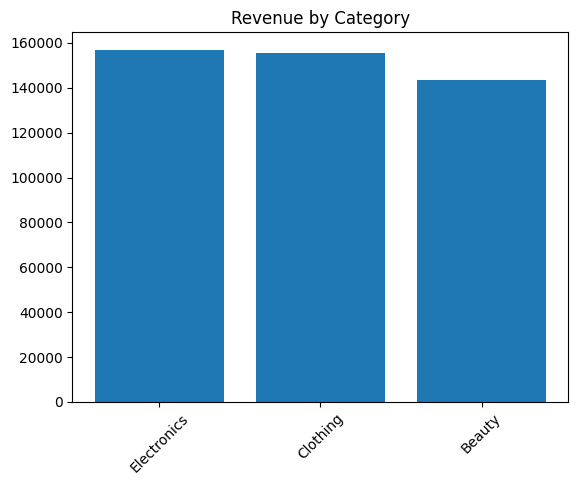

In [12]:
import matplotlib.pyplot as plt

query = """
SELECT "product category", SUM("total amount") AS revenue
FROM sales
GROUP BY "product category"
ORDER BY revenue DESC;
"""

df_plot = pd.read_sql(query, conn)

plt.figure()
plt.bar(df_plot["product category"], df_plot["revenue"])
plt.title("Revenue by Category")
plt.xticks(rotation=45)
plt.show()

## 🔍 Key Insights

- A small number of products generate the majority of revenue
- Certain regions dominate overall sales performance
- Category-level analysis shows clear demand patterns

## 🚀 Business Recommendations

- Focus marketing on high-revenue products
- Increase stock in high-performing regions
- Improve strategy for low-performing categories